# **Imports**

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ------------------------------------------
# desabilita warnings
# ------------------------------------------
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ------------------------------------------
# bibliotecas principais
# ------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [5]:
df = pd.read_csv('/content/drive/Shareddrives/grupo4-rappi-hour/bases-rappi/df-oficial.csv')

In [6]:
df = df.drop(columns = ['Unnamed: 0'])

In [7]:
df["IS_ACTIVE"].replace({
    "False": 0,
    "True": 1,
    "Quasi": 0
}, inplace=True)

## Features / Target


In [8]:
x = df.drop(columns="IS_ACTIVE") # features
y = df["IS_ACTIVE"] # target

In [9]:
from sklearn.model_selection import train_test_split


In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, 
                                                    test_size = 0.3, 
                                                    random_state = 1)

In [11]:
from sklearn.preprocessing import MinMaxScaler

# Instaciando o objeto scaler
scaler = MinMaxScaler()

# Fit + transform no conjunto de treino
# Utilizando explicitamente as colunas de ambos os lados força que o
# resultado da normalização ainda seja o dataframe (muito mais facil de manipular) e não um numpy array
x_train[list(x_train.columns)] = scaler.fit_transform(x_train[list(x_train.columns)])

# Agora utilizando o scaler no conjunto de teste
# Utilizar apenas o transform, pois fit é só no conjunto de treino,]
# o conjunto de teste é utilizado para medir a capacidade de generalização do modelo no mundo real (dados não vistos)
# então faz sentido que a mesma normalização treinada e submetida ao conjunto de treino seja apenas aplicada no de teste
x_test[list(x_test.columns)] = scaler.transform(x_test[list(x_test.columns)])

In [12]:
y_train.squeeze()

19778     2
96599     2
58231     2
11258     2
67121     2
         ..
73349     2
109259    2
50057     2
5192      1
128037    2
Name: IS_ACTIVE, Length: 110229, dtype: int64

In [13]:
y_true = y_test

# **Models**

## Logistic Regression


In [ ]:
from sklearn.linear_model import LogisticRegression

# Instaciação do obj Algoritmo
logreg = LogisticRegression()
# Treino # x = Features, y = Label/Target
logreg.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

In [ ]:
print('Acuracidade (treino): ', logreg.score( x_train, y_train ))
print('Acuracidade (teste): ', logreg.score( x_test, y_test ))

In [ ]:
y_pred_logreg = logreg.predict(x_test)

In [ ]:
cm_logreg = confusion_matrix(y_true, y_pred_logreg, normalize = 'true')
cm_logreg

In [ ]:
# versão visual mais bonita da matriz
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, 
                              display_labels=logreg.classes_)

disp_logreg.plot()
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_logreg))

In [ ]:
importance = logreg.coef_[0]
# summarize feature importance
for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
plt.bar([x for x in range(len(importance))], importance)
plt.show()

## Adaboost



In [ ]:
#from sklearn.ensemble import AdaBoostClassifier

# Instaciação do obj Algoritmo
#adaboost = AdaBoostClassifier()
# Treino # x = Features, y = Label/Target
#adaboost.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

In [ ]:
#print('Acuracidade (treino): ', adaboost.score( x_train, y_train ))
#print('Acuracidade (teste): ', adaboost.score( x_test, y_test ))

In [ ]:
#y_pred_adaboost = adaboost.predict(x_test)

In [ ]:
#cm_adaboost = confusion_matrix(y_true, y_pred_adaboost, normalize = 'true')
#cm_adaboost

In [ ]:
# versão visual mais bonita da matriz
#disp_adaboost = ConfusionMatrixDisplay(confusion_matrix=cm_adaboost, 
#                              display_labels=adaboost.classes_)

#disp_adaboost.plot()
#plt.show()

In [ ]:
#print(classification_report(y_test, y_pred_adaboost))

## Random Forest


In [14]:
from sklearn.ensemble import RandomForestClassifier

# Instaciação do obj Algoritmo
ranfor = RandomForestClassifier()
# Treino # x = Features, y = Label/Target
ranfor.fit( x_train, y_train ) # squeeze() -> df para series

RandomForestClassifier()

In [15]:
print('Acuracidade (treino): ', ranfor.score( x_train, y_train ))
print('Acuracidade (teste): ', ranfor.score( x_test, y_test ))

Acuracidade (treino):  0.9999818559544221
Acuracidade (teste):  0.8557185495649965


In [16]:
y_pred_ranfor = ranfor.predict(x_test)

In [17]:
cm_ranfor = confusion_matrix(y_true, y_pred_ranfor, normalize = 'true')
cm_ranfor

array([[9.92496589e-01, 1.70532060e-03, 5.79809004e-03],
       [1.76195930e-04, 5.33873668e-01, 4.65950137e-01],
       [0.00000000e+00, 4.93239193e-02, 9.50676081e-01]])

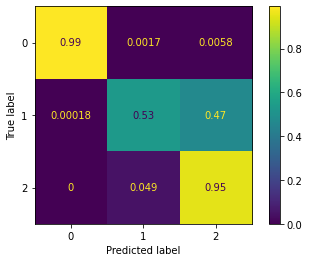

In [18]:
# versão visual mais bonita da matriz
disp_ranfor = ConfusionMatrixDisplay(confusion_matrix=cm_ranfor, 
                              display_labels=ranfor.classes_)

disp_ranfor.plot()
plt.show()

In [19]:
print(classification_report(y_test, y_pred_ranfor))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5864
           1       0.80      0.53      0.64     11351
           2       0.84      0.95      0.89     30026

    accuracy                           0.86     47241
   macro avg       0.88      0.83      0.84     47241
weighted avg       0.85      0.86      0.85     47241



## SGD


In [ ]:
#from sklearn.linear_model import SGDClassifier

# Instaciação do obj Algoritmo
#sgd = SGDClassifier()
# Treino # x = Features, y = Label/Target
#sgd.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

In [ ]:
#print('Acuracidade (treino): ', sgd.score( x_train, y_train ))
#print('Acuracidade (teste): ', sgd.score( x_test, y_test ))

In [ ]:
#y_pred_sgd = sgd.predict(x_test)

In [ ]:
#cm_sgd = confusion_matrix(y_true, y_pred_sgd, normalize = 'true')
#cm_sgd

In [ ]:
# versão visual mais bonita da matriz
#disp_sgd = ConfusionMatrixDisplay(confusion_matrix=cm_sgd, 
#                              display_labels=sgd.classes_)

#disp_sgd.plot()
#plt.show()

In [ ]:
#print(classification_report(y_test, y_pred_sgd))

## SVM


In [ ]:
#from sklearn import svm

# Instaciação do obj Algoritmo
#svm = svm.SVC()
# Treino # x = Features, y = Label/Target
#svm.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

In [ ]:
#print('Acuracidade (treino): ', svm.score( x_train, y_train ))
#print('Acuracidade (teste): ', svm.score( x_test, y_test ))

In [ ]:
#y_pred_svm = svm.predict(x_test)

In [ ]:
#cm_svm = confusion_matrix(y_true, y_pred_svm, normalize = 'true')
#cm_svm

In [ ]:
# versão visual mais bonita da matriz
#disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, 
#                              display_labels=svm.classes_)

#disp_svm.plot()
#plt.show()

In [ ]:
#print(classification_report(y_test, y_pred_svm))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Instaciação do obj Algoritmo
knn = KNeighborsClassifier(n_neighbors=5)
# Treino # x = Features, y = Label/Target
knn.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

In [ ]:
print('Acuracidade (treino): ', knn.score( x_train, y_train ))
print('Acuracidade (teste): ', knn.score( x_test, y_test ))

In [ ]:
y_pred_knn = knn.predict(x_test)

In [ ]:
cm_knn = confusion_matrix(y_true, y_pred_knn, normalize = 'true')
cm_knn

In [ ]:
# versão visual mais bonita da matriz
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, 
                              display_labels=knn.classes_)

disp_knn.plot()
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_knn))

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Instaciação do obj Algoritmo
knn = KNeighborsClassifier(n_neighbors=5)
# Treino # x = Features, y = Label/Target
knn.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

## KNN


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Instaciação do obj Algoritmo
knn = KNeighborsClassifier(n_neighbors=5)
# Treino # x = Features, y = Label/Target
knn.fit( x_train, y_train.squeeze() ) # squeeze() -> df para series

In [ ]:
print('Acuracidade (treino): ', knn.score( x_train, y_train ))
print('Acuracidade (teste): ', knn.score( x_test, y_test ))

In [ ]:
y_pred_knn = knn.predict(x_test)

In [ ]:
cm_knn = confusion_matrix(y_true, y_pred_knn, normalize = 'true')
cm_knn

In [ ]:
# versão visual mais bonita da matriz
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, 
                              display_labels=knn.classes_)

disp_knn.plot()
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_knn))

## LGBM


In [21]:
import lightgbm as lgb

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state=42)
# Criando o modelo

lgb = lgb.LGBMClassifier()

lgb.fit(x_train, y_train)


LGBMClassifier()

In [22]:
print('Acuracidade (treino): ', lgb.score( x_train, y_train ))
print('Acuracidade (teste): ', lgb.score( x_test, y_test ))

Acuracidade (treino):  0.8724201435194006
Acuracidade (teste):  0.8654981901314536


In [23]:
y_pred_lgb = lgb.predict(x_test)

In [24]:
cm_lgb = confusion_matrix(y_true, y_pred_lgb, normalize = 'true')
cm_lgb

array([[0.12141883, 0.18656207, 0.6920191 ],
       [0.11769888, 0.18923443, 0.69306669],
       [0.12116166, 0.18487311, 0.69396523]])

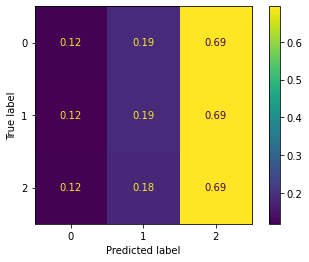

In [25]:
# versão visual mais bonita da matriz
disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb, 
                            display_labels=lgb.classes_)

disp_lgb.plot()
plt.show()

In [26]:
print(classification_report(y_test, y_pred_lgb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5710
           1       0.79      0.61      0.69     11439
           2       0.86      0.94      0.90     30092

    accuracy                           0.87     47241
   macro avg       0.88      0.85      0.86     47241
weighted avg       0.86      0.87      0.86     47241



# 

# **Cluster Resample**

In [29]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=13)
x_resampled, y_resampled = rus.fit_resample(x, y)

In [30]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x, y, 
                                                    test_size = 0.3, 
                                                    random_state = 8)

In [31]:
# Instaciando o objeto scaler
scaler = MinMaxScaler()

# Fit + transform no conjunto de treino
# Utilizando explicitamente as colunas de ambos os lados força que o
# resultado da normalização ainda seja o dataframe (muito mais facil de manipular) e não um numpy array
x_train1[list(x_train1.columns)] = scaler.fit_transform(x_train1[list(x_train1.columns)])

# Agora utilizando o scaler no conjunto de teste
# Utilizar apenas o transform, pois fit é só no conjunto de treino,]
# o conjunto de teste é utilizado para medir a capacidade de generalização do modelo no mundo real (dados não vistos)
# então faz sentido que a mesma normalização treinada e submetida ao conjunto de treino seja apenas aplicada no de teste
x_test1[list(x_test1.columns)] = scaler.transform(x_test1[list(x_test1.columns)])

In [32]:
y_train1.squeeze()

46267     2
141493    0
126779    2
146212    0
62926     2
         ..
141448    0
62426     1
149489    0
25940     1
70083     2
Name: IS_ACTIVE, Length: 110229, dtype: int64

In [33]:
y_true1 = y_test1

## Logistic Regression


In [ ]:
logreg.fit( x_train1, y_train1.squeeze() ) # squeeze() -> df para series

In [ ]:
print('Acuracidade (treino): ', logreg.score( x_train1, y_train1 ))
print('Acuracidade (teste): ', logreg.score( x_test1, y_test1 ))

In [ ]:
y_pred_logreg = logreg.predict(x_test1)

In [ ]:
cm_logreg = confusion_matrix(y_true1, y_pred_logreg, normalize = 'true')
cm_logreg

In [ ]:
# versão visual mais bonita da matriz
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, 
                              display_labels=logreg.classes_)

disp_logreg.plot()
plt.show()

In [ ]:
print(classification_report(y_test1, y_pred_logreg))

In [ ]:
importance = logreg.coef_[0]
# summarize feature importance
for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
plt.bar([x_resampled for x_resampled in range(len(importance))], importance)
plt.show()

## Adaboost



In [ ]:
#adaboost.fit( x_train1, y_train1.squeeze() ) # squeeze() -> df para series

In [ ]:
#print('Acuracidade (treino): ', adaboost.score( x_train1, y_train1 ))
#print('Acuracidade (teste): ', adaboost.score( x_test1, y_test1 ))

In [ ]:
#y_pred_adaboost = adaboost.predict(x_test1)

In [ ]:
#cm_adaboost = confusion_matrix(y_true1, y_pred_adaboost, normalize = 'true')
#cm_adaboost

In [ ]:
# versão visual mais bonita da matriz
#disp_adaboost = ConfusionMatrixDisplay(confusion_matrix=cm_adaboost, 
#                              display_labels=adaboost.classes_)

#disp_adaboost.plot()
#plt.show()

In [ ]:
#print(classification_report(y_test1, y_pred_adaboost))

## Random Forest


In [34]:
ranfor.fit( x_train1, y_train1 ) # squeeze() -> df para series

RandomForestClassifier()

In [35]:
print('Acuracidade (treino): ', ranfor.score( x_train1, y_train1 ))
print('Acuracidade (teste): ', ranfor.score( x_test1, y_test1 ))

Acuracidade (treino):  0.9999909279772111
Acuracidade (teste):  0.8572426493935352


In [36]:
y_pred_ranfor = ranfor.predict(x_test1)

In [37]:
cm_ranfor = confusion_matrix(y_true1, y_pred_ranfor, normalize = 'true')
cm_ranfor

array([[9.92317094e-01, 2.61917234e-03, 5.06373319e-03],
       [0.00000000e+00, 5.47365643e-01, 4.52634357e-01],
       [2.32210980e-04, 5.13186266e-02, 9.48449162e-01]])

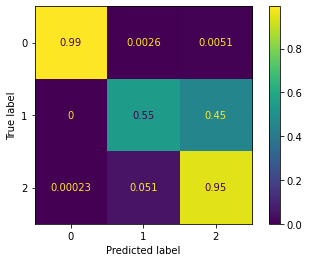

In [38]:
# versão visual mais bonita da matriz
disp_ranfor = ConfusionMatrixDisplay(confusion_matrix=cm_ranfor, 
                             display_labels=ranfor.classes_)

disp_ranfor.plot()
plt.show()

In [39]:
print(classification_report(y_test1, y_pred_ranfor))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5727
           1       0.80      0.55      0.65     11369
           2       0.85      0.95      0.89     30145

    accuracy                           0.86     47241
   macro avg       0.88      0.83      0.85     47241
weighted avg       0.85      0.86      0.85     47241



## SGD


In [ ]:
#sgd.fit( x_train1, y_train1.squeeze() ) # squeeze() -> df para series

In [ ]:
#print('Acuracidade (treino): ', sgd.score( x_train1, y_train1 ))
#print('Acuracidade (teste): ', sgd.score( x_test1, y_test1 ))

In [ ]:
#y_pred_sgd = sgd.predict(x_test1)

In [ ]:
#cm_sgd = confusion_matrix(y_true1, y_pred_sgd, normalize = 'true')
#cm_sgd

In [ ]:
# versão visual mais bonita da matriz
#disp_sgd = ConfusionMatrixDisplay(confusion_matrix=cm_sgd, 
#                              display_labels=sgd.classes_)

#disp_sgd.plot()
#plt.show()

In [ ]:
#print(classification_report(y_test1, y_pred_sgd))

## LGB

In [40]:
lgb.fit(x_train1, y_train1)

LGBMClassifier()

In [41]:
print('Acuracidade (treino): ', lgb.score( x_train1, y_train1 ))
print('Acuracidade (teste): ', lgb.score( x_test1, y_test1 ))

Acuracidade (treino):  0.8726650881347013
Acuracidade (teste):  0.8673398107576046


In [42]:
y_pred_lgb = lgb.predict(x_test1)

In [43]:
cm_lgb = confusion_matrix(y_true1, y_pred_lgb, normalize = 'true')
cm_lgb

array([[9.92491706e-01, 2.26994936e-03, 5.23834468e-03],
       [2.63875451e-04, 6.09112499e-01, 3.90623626e-01],
       [1.99037983e-04, 5.88488970e-02, 9.40952065e-01]])

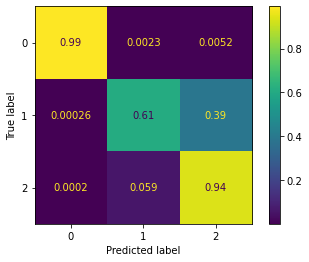

In [44]:
# versão visual mais bonita da matriz
disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb, 
                              display_labels=lgb.classes_)

disp_lgb.plot()
plt.show()

In [45]:
print(classification_report(y_test1, y_pred_lgb))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5727
           1       0.79      0.61      0.69     11369
           2       0.86      0.94      0.90     30145

    accuracy                           0.87     47241
   macro avg       0.89      0.85      0.86     47241
weighted avg       0.86      0.87      0.86     47241



## KNN


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Instaciação do obj Algoritmo
knn = KNeighborsClassifier(n_neighbors= 21)
# Treino # x = Features, y = Label/Target
knn.fit( x_train1, y_train1.squeeze() ) # squeeze() -> df para series

In [ ]:
print('Acuracidade (treino): ', knn.score( x_train1, y_train1 ))
print('Acuracidade (teste): ', knn.score( x_test1, y_test1 ))

In [ ]:
y_pred_knn = knn.predict(x_test1)

In [ ]:
cm_knn = confusion_matrix(y_true1, y_pred_knn, normalize = 'true')
cm_knn

In [ ]:
# versão visual mais bonita da matriz
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, 
                              display_labels=knn.classes_)

disp_knn.plot()
plt.show()

In [ ]:
print(classification_report(y_test1, y_pred_knn))

## SVM


In [ ]:
#svm.fit( x_train1, y_train1.squeeze() ) # squeeze() -> df para series

In [ ]:
#print('Acuracidade (treino): ', svm.score( x_train1, y_train1 ))
#print('Acuracidade (teste): ', svm.score( x_test1, y_test1 ))

In [ ]:
#y_pred_svm = svm.predict(x_test1)

In [ ]:
#cm_svm = confusion_matrix(y_true1, y_pred_svm, normalize = 'true')
#cm_svm

In [ ]:
# versão visual mais bonita da matriz
#disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, 
#                              display_labels=svm.classes_)

#disp_svm.plot()
#plt.show()

In [ ]:
#print(classification_report(y_test1, y_pred_svm))